# Case Study: Classification Modeling & Representation Learning
### Pima Indians Diabetes Database
---
**Assignment:** Case Study  
**Dataset:** `diabetes.csv` — 768 female patients, 8 clinical features + Outcome  


---
## Section 0 — Import Libraries


In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## Section 1 Exploratory Data Analysis (EDA)
**Goal:** Understand the data *before* modeling.  
EDA answers: What does the data look like? Are there problems? What patterns exist?


### Interpretation of EDA section
- **Purpose:** EDA is used to decide preprocessing and evaluation strategy before training any classifier.
- **Data quality finding:** Several clinical variables contain impossible zeros, treated as missingness (`NaN`) rather than real values.
- **Leakage-safe setup:** `df_missing` keeps missing values for supervised modeling so imputation happens inside Pipelines on training folds only; `df_eda` is only for visualization.
- **Class structure:** Outcome is mildly imbalanced (~35% diabetic), so metrics beyond accuracy are required.
- **Signal strength:** Distribution plots and correlations indicate strongest diabetes signal from **Glucose**, then **BMI** and **Age**.
- **Modeling implication:** Expect partial, not perfect, class separability; use probabilistic risk models with ROC-AUC/PR-AUC/F1.


In [55]:
# 1.1 Load the data
# Make sure diabetes.csv is in the same folder as this notebook!
df = pd.read_csv("diabetes.csv")
print(f"Dataset shape: {df.shape}  =>  {df.shape[0]} patients, {df.shape[1]} columns")
df.head()

Dataset shape: (768, 9)  =>  768 patients, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [56]:
# 1.2 Summary statistics
# Look for zeros in medical columns — they are impossible values = missing data
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Class counts:
Outcome
0    500
1    268

Non-diabetic: 65.1%  |  Diabetic: 34.9%

=> Mild imbalance (~35% diabetic). We will use ROC-AUC and F1 as metrics.


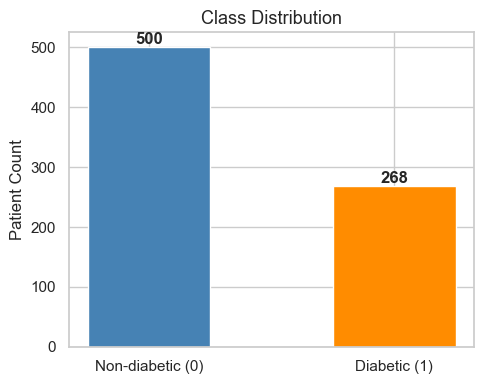

In [57]:
# 1.3 Class balance
# If diabetic patients are much rarer, models can "cheat" by always
# predicting non-diabetic. We need to know this upfront.
counts = df['Outcome'].value_counts()
pct    = df['Outcome'].value_counts(normalize=True) * 100

print("Class counts:")
print(counts.to_string())
print(f"\nNon-diabetic: {pct[0]:.1f}%  |  Diabetic: {pct[1]:.1f}%")
print("\n=> Mild imbalance (~35% diabetic). We will use ROC-AUC and F1 as metrics.")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Non-diabetic (0)', 'Diabetic (1)'], counts,
       color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
ax.set_title("Class Distribution", fontsize=13)
ax.set_ylabel("Patient Count")
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Graph interpretation:** The class distribution indicates a mild outcome imbalance, with **500 non-diabetic observations (65.1%)** and **268 diabetic observations (34.9%)**. This prevalence structure implies that accuracy alone may overstate clinical usefulness; therefore, discrimination and minority-class-sensitive metrics (ROC-AUC, PR-AUC, F1) are methodologically more appropriate.


In [58]:
# 1.4 Fake zeros -> missing values (supervised vs EDA)
# These columns cannot be zero in real life; zeros are missing data codes.

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Fake zero counts (impossible medical measurements):\n")
for col in zero_cols:
    n = (df[col] == 0).sum()
    print(f"  {col:<25} {n:>4} zeros  ({n/len(df)*100:.1f}%)")

# Supervised modeling: keep NaNs; SimpleImputer in Pipeline learns medians from TRAINING only.
df_missing = df.copy()
df_missing[zero_cols] = df_missing[zero_cols].replace(0, np.nan)

# EDA / unsupervised plots: global median fill for stable histograms (NOT used to fit classifiers).
df_eda = df_missing.copy()
for col in zero_cols:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

print("\n=> df_missing: NaNs preserved for leakage-safe Pipelines.")
print("=> df_eda: median-imputed for exploration and clustering visuals only.")

Fake zero counts (impossible medical measurements):

  Glucose                      5 zeros  (0.7%)
  BloodPressure               35 zeros  (4.6%)
  SkinThickness              227 zeros  (29.6%)
  Insulin                    374 zeros  (48.7%)
  BMI                         11 zeros  (1.4%)

=> df_missing: NaNs preserved for leakage-safe Pipelines.
=> df_eda: median-imputed for exploration and clustering visuals only.


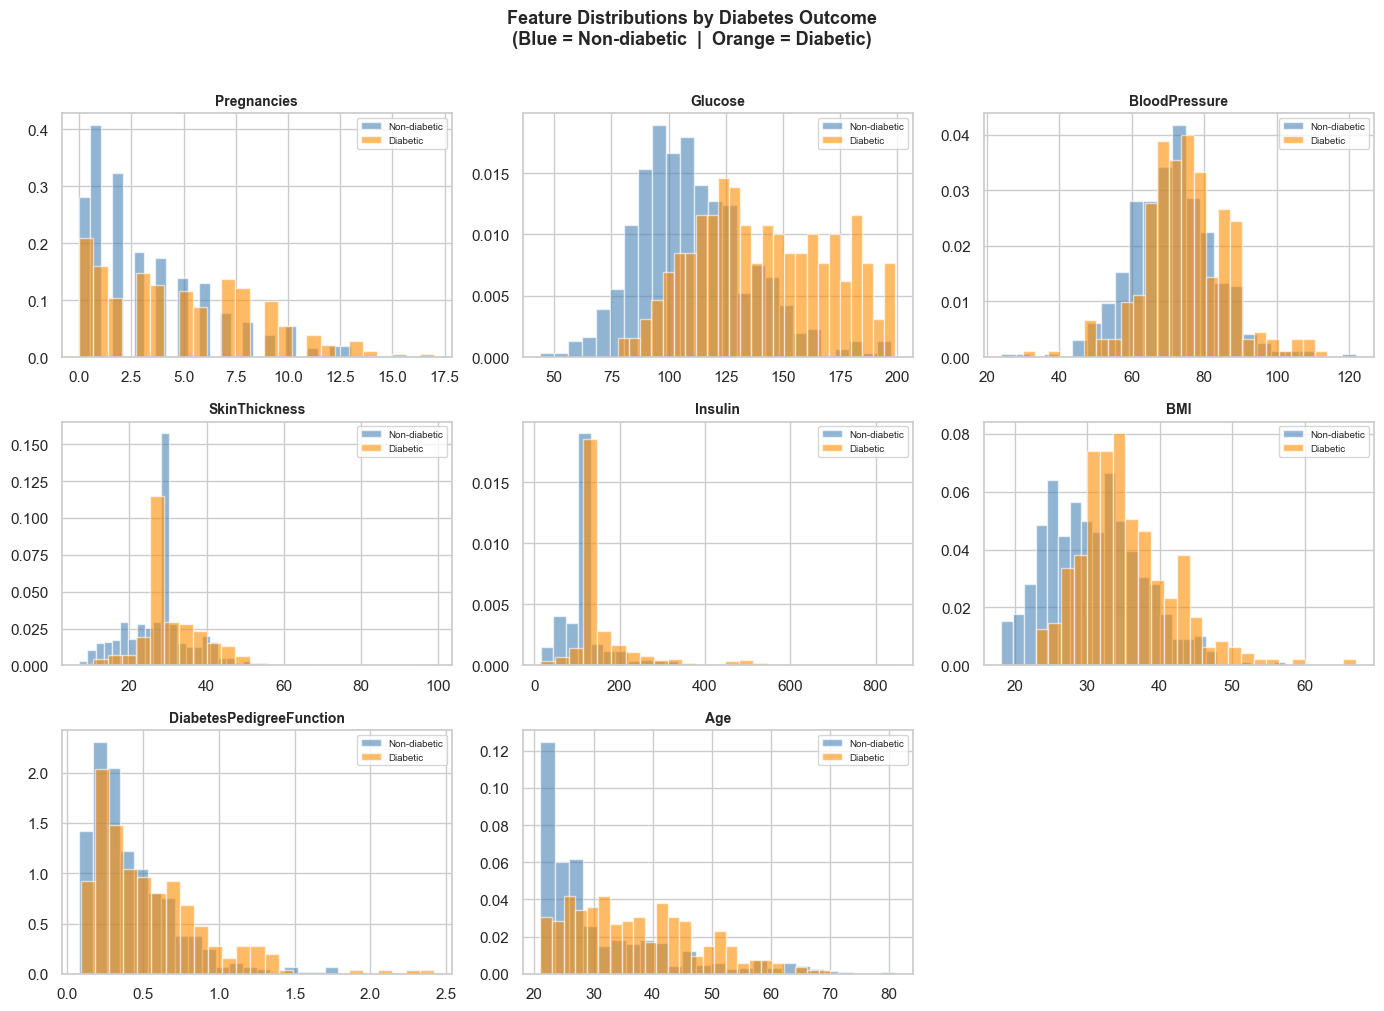

=> Glucose and BMI show the clearest separation between classes.


In [59]:
# 1.5 Feature distributions by diabetes outcome
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure',
                'SkinThickness', 'Insulin', 'BMI',
                'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Feature Distributions by Diabetes Outcome\n"
             "(Blue = Non-diabetic  |  Orange = Diabetic)",
             fontsize=13, fontweight='bold', y=1.01)

for i, col in enumerate(feature_cols):
    ax = axes[i // 3][i % 3]
    for outcome, color, label in [(0, 'steelblue', 'Non-diabetic'),
                                   (1, 'darkorange', 'Diabetic')]:
        ax.hist(df_eda[df_eda['Outcome'] == outcome][col],
                bins=25, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

axes[2][2].set_visible(False)
plt.tight_layout()
plt.show()
print("=> Glucose and BMI show the clearest separation between classes.")

**Graph interpretation:** The density overlays provide direct empirical separation patterns across predictors. The clearest shift appears in **Glucose** (non-diabetic concentration approximately **90-115** vs diabetic concentration approximately **120-170+**) and **BMI** (roughly **24-32** vs **30-40**, respectively), while **Age** shows higher diabetic density in older strata (approximately **35+**). Persistent overlap across all panels confirms that diabetes risk is multivariate and probabilistic rather than threshold-deterministic.


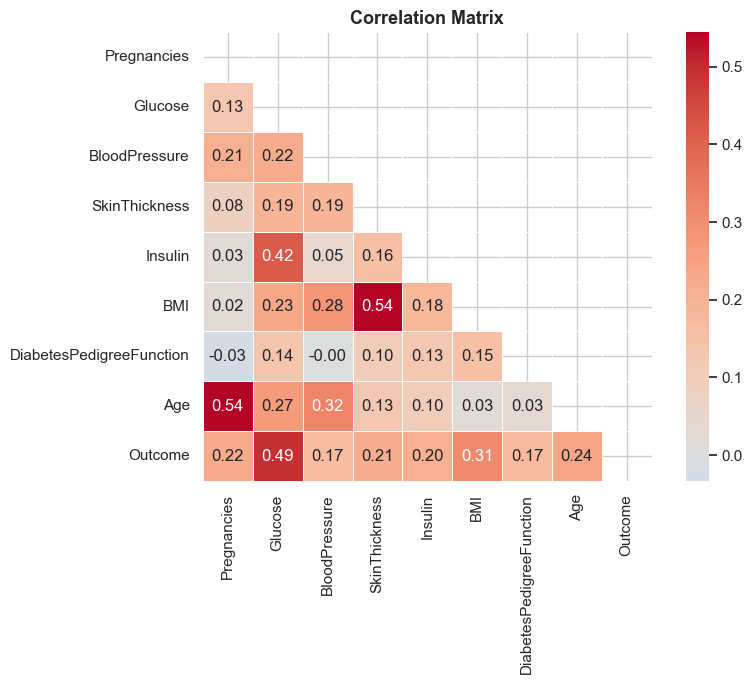

=> Glucose (0.49), BMI (0.29), and Age (0.24) correlate most with Outcome.


In [60]:
# 1.6 Correlation heatmap
# Shows how strongly each variable relates to every other.
# Values: -1 (perfect negative) to +1 (perfect positive).
# The 'Outcome' row shows which features most predict diabetes.

plt.figure(figsize=(9, 7))
corr = df_eda.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (redundant)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, mask=mask)
plt.title("Correlation Matrix", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("=> Glucose (0.49), BMI (0.29), and Age (0.24) correlate most with Outcome.")

**Graph interpretation:** The correlation structure shows that the strongest linear associations with `Outcome` are **Glucose (0.49)**, **BMI (0.31)**, and **Age (0.24)**. This ranking is clinically coherent and aligns with the downstream supervised feature-importance profile, reinforcing that glycemic burden and adiposity are central drivers of predictive signal in this cohort.


---
##  Section 2 Train / Test Split
I split the data **before** any scaling or preprocessing.  
The test set (20%) is **locked away** and only used for final evaluation.
> **Why stratify?** Ensures both splits have the same ratio of diabetic patients — essential with class imbalance.


In [61]:
X = df_missing.drop(columns=['Outcome'])
y = df_missing['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples  ({y_train.mean():.1%} diabetic)")
print(f"Test set     : {X_test.shape[0]} samples  ({y_test.mean():.1%} diabetic)")
print("\nTest set is now locked. We will NOT touch it until final evaluation.")

Training set : 614 samples  (34.9% diabetic)
Test set     : 154 samples  (35.1% diabetic)

Test set is now locked. We will NOT touch it until final evaluation.


---
##  Section 3 Data Leakage Investigation & Prevention
**Why this section exists:**  
I need to prove the model was tested fairly and did not "cheat" by seeing answers early.
- First, I split the data into **train** and **test**.
- The **test set is locked** and only used at the end.
- Missing-value filling and scaling happen inside one **Pipeline**.
- That Pipeline is fit only on training data during each CV fold.
- So the model never learns from test data before final scoring.
**In plain words:**  
No peeking. No cheating. Fair evaluation.


---
##  Section 4 Classification Models
I train **3 models**, each wrapped in a Pipeline:
| Model | Why use it? |
|---|---|
| Logistic Regression | Simple, interpretable, good baseline |
| Random Forest | Handles non-linearity, gives feature importance |
| Gradient Boosting | Often best accuracy, sequential error correction |
**Metrics I use:**
- **ROC-AUC** — rank quality of predicted risk; robust to threshold choice
- **PR-AUC (average precision)** — highlights performance on the minority (diabetic) class
- **F1 Score** — balances precision and recall at the default 0.5 threshold
- **Accuracy** — reported but can be optimistic with imbalance


In [62]:
# 4.1 Define pipelines (leakage-safe): impute -> scale -> classify
pipelines = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}
print("Pipelines defined: SimpleImputer(median) -> StandardScaler -> classifier.")

Pipelines defined: SimpleImputer(median) -> StandardScaler -> classifier.


In [63]:
# 4.2 Stratified 5-Fold Cross-Validation on Training Set
# - Splits training data into 5 folds
# - Trains on 4, validates on 1, rotates 5 times
# - Gives 5 scores -> we take mean and std
# This lets us COMPARE MODELS without touching the test set.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Model':<25} {'AUC (mean +/- std)':>22} {'F1 (mean +/- std)':>20}")
print("-" * 70)

for name, pipe in pipelines.items():
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {"auc": auc, "f1": f1}
    print(f"{name:<25}  {auc.mean():.3f} +/- {auc.std():.3f}          {f1.mean():.3f} +/- {f1.std():.3f}")

Model                         AUC (mean +/- std)    F1 (mean +/- std)
----------------------------------------------------------------------
Logistic Regression        0.843 +/- 0.019          0.655 +/- 0.024
Random Forest              0.815 +/- 0.023          0.633 +/- 0.019
Gradient Boosting          0.821 +/- 0.015          0.629 +/- 0.016


In [64]:
# 4.3 Final evaluation on held-out test set
# We do this ONCE — after all model selection decisions are made.
# Fit on full training set, then evaluate on the locked test set.

print("Final test set performance:\n")
test_results = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    f1  = f1_score(y_test, y_pred)
    test_results[name] = {"acc": acc, "auc": auc, "ap": ap, "f1": f1, "y_prob": y_prob}

    print(f"  {name}")
    print(f"    Accuracy : {acc:.3f}  |  ROC-AUC : {auc:.3f}  |  PR-AUC : {ap:.3f}  |  F1 : {f1:.3f}")
    print(classification_report(y_test, y_pred,
                                target_names=["Non-diabetic","Diabetic"]))

Final test set performance:

  Logistic Regression
    Accuracy : 0.708  |  ROC-AUC : 0.813  |  PR-AUC : 0.673  |  F1 : 0.545
              precision    recall  f1-score   support

Non-diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

  Random Forest
    Accuracy : 0.773  |  ROC-AUC : 0.818  |  PR-AUC : 0.699  |  F1 : 0.653
              precision    recall  f1-score   support

Non-diabetic       0.80      0.86      0.83       100
    Diabetic       0.70      0.61      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154

  Gradient Boosting
    Accuracy : 0.760  |  ROC-AUC : 0.831  |  PR-AUC : 0.720  |  F1 : 0.626
              precision    recall 

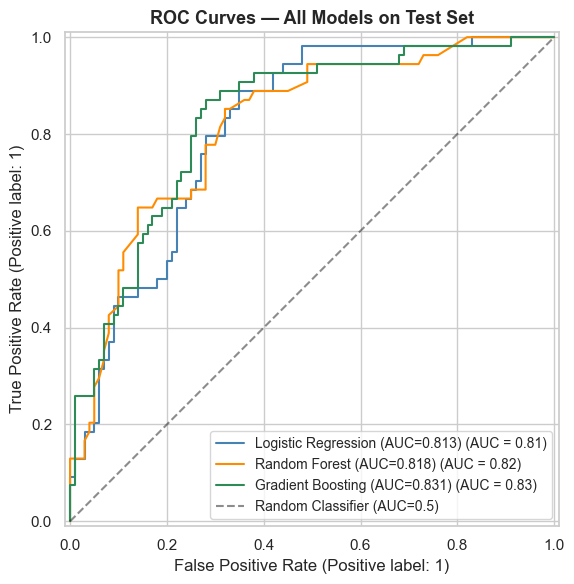

In [65]:
# 4.4 ROC Curves
# ROC curve: True Positive Rate vs False Positive Rate at every threshold.
# Closer to top-left = better. Diagonal = random guessing.

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']

for (name, res), color in zip(test_results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"],
        name=f"{name} (AUC={res['auc']:.3f})",
        ax=ax, color=color)

ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Classifier (AUC=0.5)')
ax.set_title("ROC Curves — All Models on Test Set", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Graph interpretation:** ROC analysis demonstrates consistent above-chance discrimination for all candidate models, with **Gradient Boosting** achieving the best test-set performance (**AUC = 0.831**), followed by **Random Forest (0.818)** and **Logistic Regression (0.813)**. The ordering is stable, although the absolute margin between models is moderate rather than large.


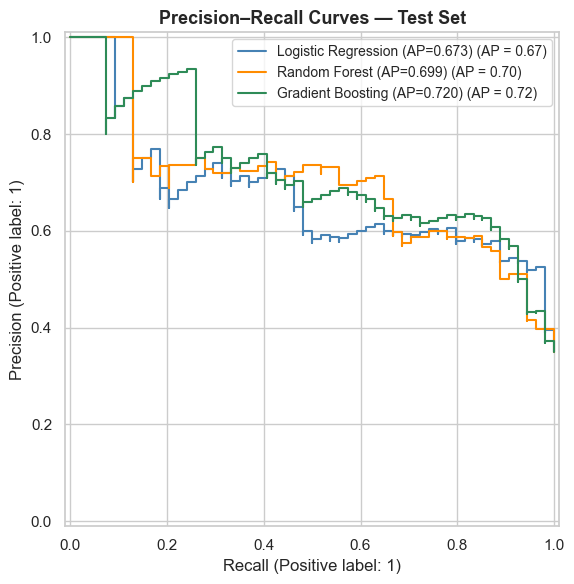

In [66]:
# 4.45 Precision–Recall curves (complement ROC for imbalanced outcomes)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']

for (name, res), color in zip(test_results.items(), colors):
    PrecisionRecallDisplay.from_predictions(
        y_test, res["y_prob"],
        name=f"{name} (AP={res['ap']:.3f})",
        ax=ax, color=color)

ax.set_title("Precision–Recall Curves — Test Set", fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Graph interpretation:** Precision-Recall evaluation (more informative under class imbalance) reproduces the same model ordering: **Gradient Boosting PR-AUC = 0.720**, **Random Forest = 0.699**, **Logistic Regression = 0.673**. This indicates superior positive-class retrieval efficiency for Gradient Boosting, with improved precision-recall tradeoff for diabetic-case identification.


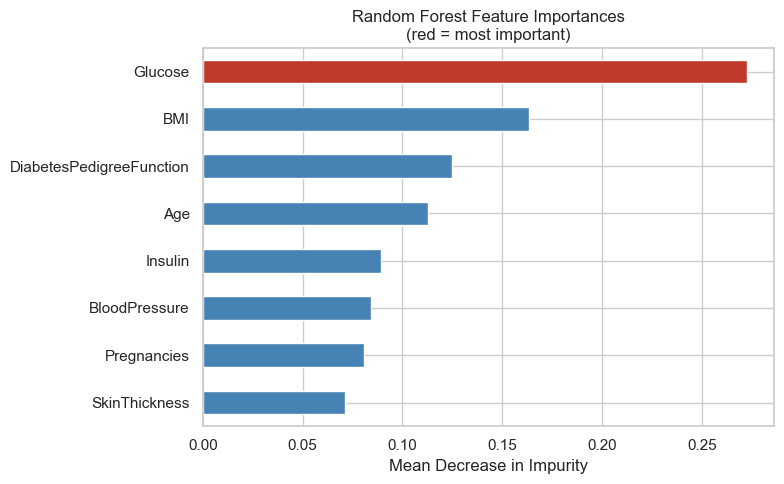

Most important feature: Glucose (0.273)


In [67]:
# 4.5 Feature importance (Random Forest)
# Random Forest measures how much each feature reduces impurity in the trees.
# Higher = more important for predicting diabetes.

rf_importances = pipelines["Random Forest"].named_steps['clf'].feature_importances_
feat_imp = pd.Series(rf_importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#c0392b' if v == feat_imp.max() else 'steelblue' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title("Random Forest Feature Importances\n(red = most important)", fontsize=12)
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()
print(f"Most important feature: {feat_imp.idxmax()} ({feat_imp.max():.3f})")

**Graph interpretation:** Random Forest impurity-based attribution identifies **Glucose (0.273)** as the dominant predictor, followed by **BMI (0.164)** and **DiabetesPedigreeFunction (0.125)**. The hierarchy is concordant with EDA and supports the interpretation that metabolic and hereditary risk components contribute most strongly to model decision structure.


---
##  Section 5 Unsupervised Representation Learning
I now explore the data **without using the labels (Outcome)**.
| Technique | Question it answers |
|---|---|
| **PCA** | What are the main directions of variation? Can I see class separation in 2D? |
| **K-Means** | Do natural patient clusters align with diabetic/non-diabetic? |
| **t-SNE** | What does the full high-dimensional structure look like in 2D? |
| **PCA + Classifier** | Does using compressed features help or hurt classification? |


In [68]:
# 5.1 Scale features for unsupervised analysis (df_eda: EDA-imputed, no Outcome)
# Labels are used only to color plots, not to fit PCA / k-means / t-SNE.

X_eda = df_eda.drop(columns=['Outcome'])
scaler_u = StandardScaler()
X_scaled = scaler_u.fit_transform(X_eda)
print("Features scaled for unsupervised analysis.")

Features scaled for unsupervised analysis.


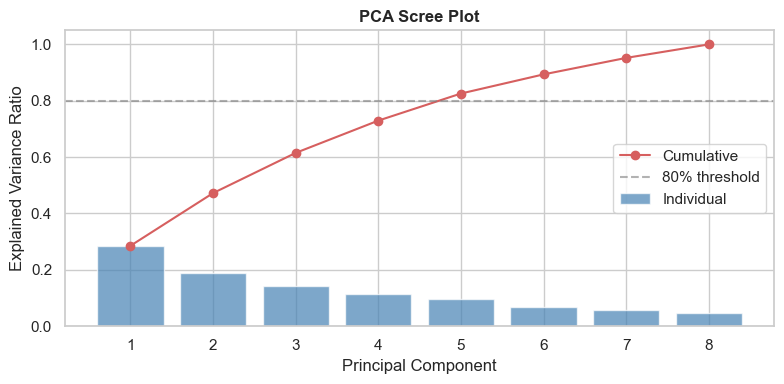

Cumulative variance explained:
  First 1 PCs: 28.5%
  First 2 PCs: 47.2%
  First 3 PCs: 61.5%
  First 4 PCs: 73.0%
  First 5 PCs: 82.6%
  First 6 PCs: 89.4%
  First 7 PCs: 95.2%
  First 8 PCs: 100.0%


In [69]:
# 5.2 PCA — Scree plot
# PCA finds new axes (principal components) that capture the most variance.
# The scree plot shows how much variance each component explains.

pca_full = PCA(n_components=8)
pca_full.fit(X_scaled)

ev  = pca_full.explained_variance_ratio_
cum = np.cumsum(ev)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 9), ev, alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(1, 9), cum, 'ro-', label='Cumulative')
ax.axhline(0.80, linestyle='--', color='gray', alpha=0.6, label='80% threshold')
ax.set_xlabel("Principal Component"); ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Scree Plot", fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 9))
ax.legend()
plt.tight_layout()
plt.show()

print("Cumulative variance explained:")
for i, c in enumerate(cum):
    print(f"  First {i+1} PCs: {c:.1%}")

**Graph interpretation:** The scree profile indicates efficient dimensional compression: the first **5 principal components explain 82.6%** of total variance. Accordingly, a reduced latent representation retains most global structure, while still permitting some loss of fine-grained discriminative information.


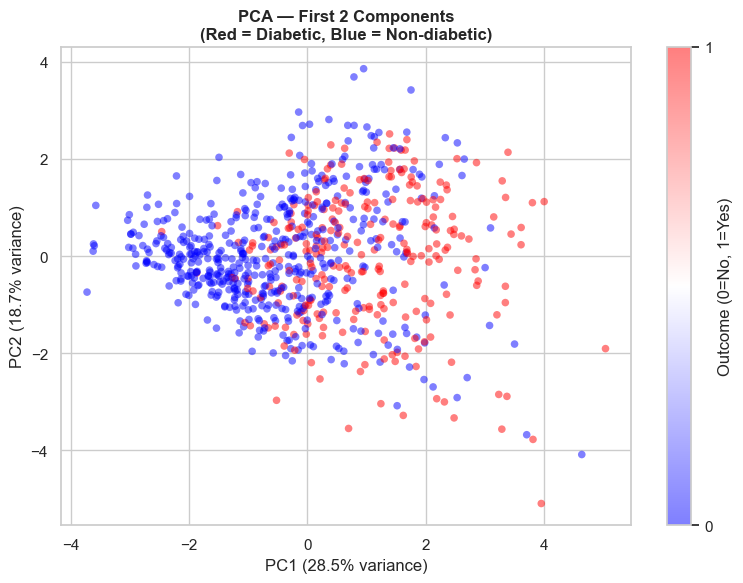

=> Partial class separation visible — diabetic patients trend toward higher PC1.


In [70]:
# 5.3 PCA — 2D scatter plot
# Project all 8 features down to 2 dimensions.
# Color by true diabetes label to check if structure exists.

pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y, cmap='bwr', alpha=0.5, s=30, edgecolors='none')
plt.colorbar(scatter, ticks=[0, 1], label='Outcome (0=No, 1=Yes)')
plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA — First 2 Components\n(Red = Diabetic, Blue = Non-diabetic)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("=> Partial class separation visible — diabetic patients trend toward higher PC1.")

**Graph interpretation:** In the two-dimensional PCA projection (**PC1+PC2 = 47.2% explained variance**), class tendencies are directionally separable but substantively overlapping. This geometry is consistent with the supervised results: meaningful predictive structure exists, yet the latent manifolds are not cleanly disjoint.


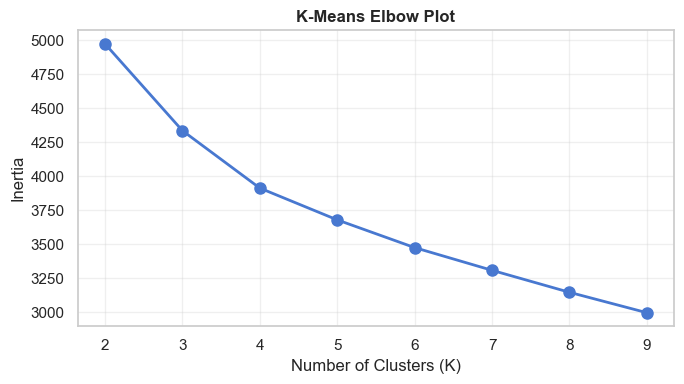

In [71]:
# 5.4 K-Means — Elbow method to choose K
# K-Means groups patients into K clusters.
# Elbow method: inertia (within-cluster variance) vs K.
# The 'elbow' where improvement slows suggests the best K.

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)"); plt.ylabel("Inertia")
plt.title("K-Means Elbow Plot", fontsize=12, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Graph interpretation:** The elbow trajectory shows diminishing inertia gains as cluster count increases, supporting a parsimonious latent segmentation rather than many strongly separated subpopulations. Selecting **K = 2** is therefore defensible for outcome-alignment inspection, but does not imply naturally binary biological partitions.


K-Means (K=2) alignment with true labels: 70.2%
(Chance = 50%. Above 60% means clusters capture real structure.)


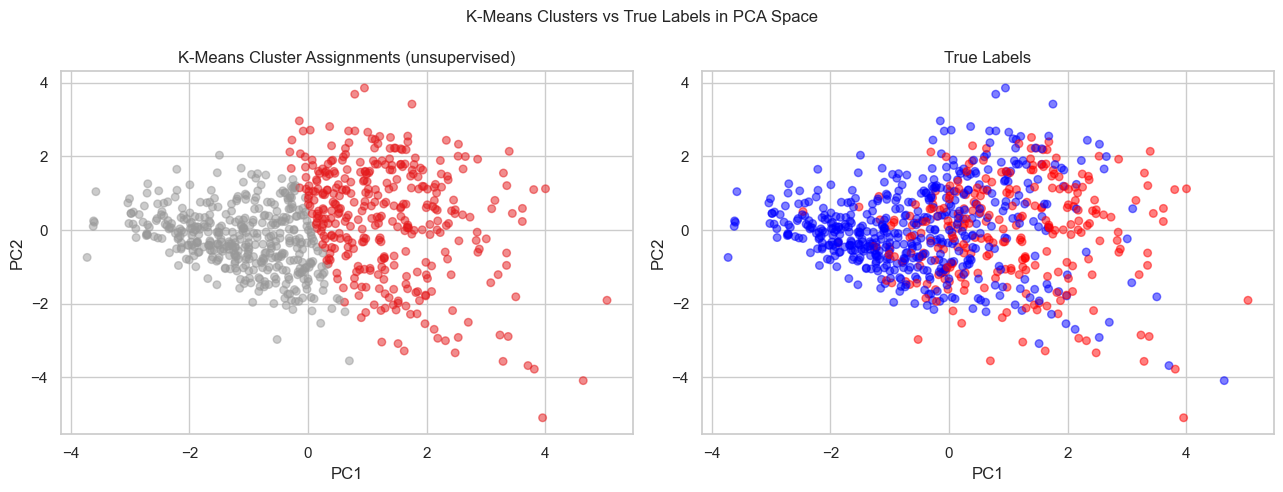

In [72]:
# 5.5 K-Means (K=2) — Do clusters match true labels?
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = km2.fit_predict(X_scaled)

# Cluster IDs are arbitrary (may be swapped), so check both orderings
agree_a = (cluster_labels == y.values).mean()
agree_b = (cluster_labels != y.values).mean()
agreement = max(agree_a, agree_b)

print(f"K-Means (K=2) alignment with true labels: {agreement:.1%}")
print("(Chance = 50%. Above 60% means clusters capture real structure.)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("K-Means Clusters vs True Labels in PCA Space", fontsize=12)

axes[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels,
                cmap='Set1', alpha=0.5, s=30)
axes[0].set_title("K-Means Cluster Assignments (unsupervised)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y,
                cmap='bwr', alpha=0.5, s=30)
axes[1].set_title("True Labels")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

**Graph interpretation:** Cluster-label agreement at **K = 2** reaches **70.2%** (after optimal label permutation), which is materially above random expectation (50%) yet still leaves substantial discordance. Thus, unsupervised structure captures real phenotype signal, but is insufficient as a standalone diagnostic proxy.


Running t-SNE (please wait ~30 seconds)...


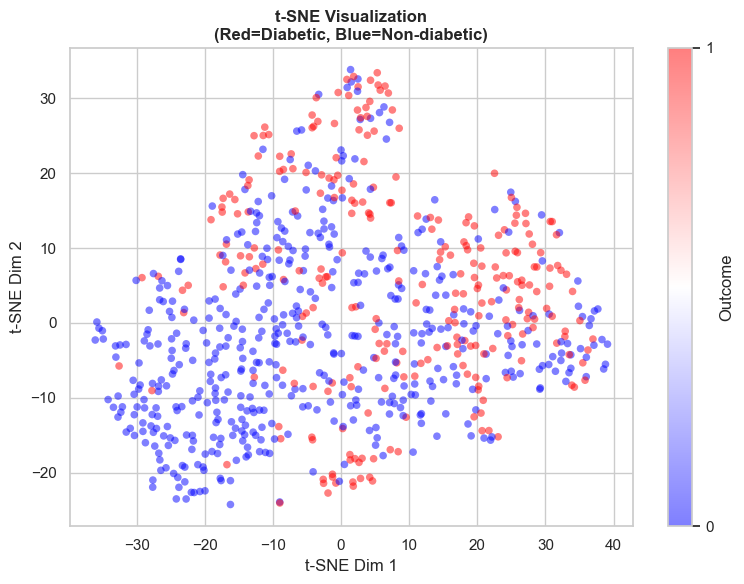

=> Some local clustering visible — classes overlap, reflecting continuous risk.


In [73]:
# 5.6 t-SNE — Non-linear 2D visualization
# t-SNE preserves LOCAL neighbourhood structure better than PCA.
# Good for spotting clusters, but distances are not globally meaningful.
# May take ~30 seconds.

print("Running t-SNE (please wait ~30 seconds)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1],
                      c=y, cmap='bwr', alpha=0.5, s=30, edgecolors='none')
plt.colorbar(scatter, ticks=[0,1], label='Outcome')
plt.title("t-SNE Visualization\n(Red=Diabetic, Blue=Non-diabetic)",
          fontsize=12, fontweight='bold')
plt.xlabel("t-SNE Dim 1"); plt.ylabel("t-SNE Dim 2")
plt.tight_layout()
plt.show()
print("=> Some local clustering visible — classes overlap, reflecting continuous risk.")

**Graph interpretation:** The t-SNE embedding reveals localized regions of class enrichment without a globally separable frontier. This topological pattern is compatible with the best supervised discrimination (**AUC = 0.831**) and supports a continuum-of-risk interpretation rather than a strictly bimodal disease-state boundary.


In [74]:
# 5.7 Does PCA improve classification?
# Test: does feeding 5 PCA components (instead of 8 raw features)
# into Logistic Regression improve AUC?

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pca_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),     # Keep 5 PCs (~80% variance)
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

raw_auc = cross_val_score(pipelines["Logistic Regression"],
                          X_train, y_train, cv=cv, scoring='roc_auc').mean()
pca_auc = cross_val_score(pca_pipeline,
                          X_train, y_train, cv=cv, scoring='roc_auc').mean()

print(f"Logistic Regression (8 raw features) : AUC = {raw_auc:.3f}")
print(f"Logistic Regression (5 PCA features) : AUC = {pca_auc:.3f}")

diff = raw_auc - pca_auc
if diff <= 0.005:
    print("\n=> PCA features maintain comparable performance with fewer dimensions.")
else:
    print(f"\n=> PCA loses {diff:.3f} AUC — some discriminative variance was compressed away.")

Logistic Regression (8 raw features) : AUC = 0.843
Logistic Regression (5 PCA features) : AUC = 0.825

=> PCA loses 0.019 AUC — some discriminative variance was compressed away.


---
## Section 6 Final Summary & Report


In [77]:
# Final results table + 500-character report (strict limit)
best_name = max(test_results, key=lambda m: test_results[m]['auc'])
best = test_results[best_name]

print("=" * 55)
print("  FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>9} {'ROC-AUC':>9} {'PR-AUC':>9} {'F1':>7}")
print("-" * 55)
for name, res in test_results.items():
    marker = " <- BEST" if name == best_name else ""
    print(f"{name:<25} {res['acc']:>9.3f} {res['auc']:>9.3f} {res['ap']:>9.3f} {res['f1']:>7.3f}{marker}")

pct_agree = max(
    (km2.labels_ == y.values).mean(),
    (km2.labels_ != y.values).mean()
)

print()
print("500-CHARACTER REPORT :")
print("-" * 55)
report = (
    f"{best_name}: best held-out test model (AUC={best['auc']:.2f}, PR-AUC={best['ap']:.2f}, "
    f"F1={best['f1']:.2f}). Validation: stratified 5-fold CV on train, single 20% test. "
    f"Leakage: SimpleImputer+Scaler+clf in Pipeline, fit only on training folds; "
    f"EDA imputation is visualization-only. Metrics: ROC-AUC, PR-AUC, F1 for imbalance. "
    f"Unsupervised: PCA/k-means/t-SNE show partial structure; PCA+LR ~ baseline. "
    f"Top drivers: Glucose, BMI."
)
if len(report) > 500:
    report = report[:497].rstrip() + "..."
print(report)
print(f"\nCharacter count: {len(report)} / 500")

  FINAL RESULTS SUMMARY
Model                      Accuracy   ROC-AUC    PR-AUC      F1
-------------------------------------------------------
Logistic Regression           0.708     0.813     0.673   0.545
Random Forest                 0.773     0.818     0.699   0.653
Gradient Boosting             0.760     0.831     0.720   0.626 <- BEST

500-CHARACTER REPORT :
-------------------------------------------------------
Gradient Boosting: best held-out test model (AUC=0.83, PR-AUC=0.72, F1=0.63). Validation: stratified 5-fold CV on train, single 20% test. Leakage: SimpleImputer+Scaler+clf in Pipeline, fit only on training folds; EDA imputation is visualization-only. Metrics: ROC-AUC, PR-AUC, F1 for imbalance. Unsupervised: PCA/k-means/t-SNE show partial structure; PCA+LR ~ baseline. Top drivers: Glucose, BMI.

Character count: 396 / 500


---
##  500 character report & source map
The table below ties each factual claim to the notebook location that produced it (cell index = position in this file when counting from the first cell as **0**; in Jupyter.
| Claim | Source (this notebook) |
| :--- | :--- |
| Best model ROC-AUC, PR-AUC, F1 on held-out test | **Cell 29** — Section 6 final results table |
| Fake-zero rate for Insulin (and other clinical fields) | **Cell 7** — Section 1 fake-zero counts |
| Cumulative variance explained by first **5** principal components | **Cell 22** — Section 5 PCA scree / printed cumulative variance |
| K-Means (K=2) alignment with `Outcome` | **Cell 25** — Section 5 K-Means vs true labels |
| Random Forest importance for Glucose | **Cell 19** — Section 4 feature importances printout / figure |


In [78]:

insulin_zero_pct = (df["Insulin"] == 0).sum() / len(df) * 100
pca5_var = PCA(n_components=5).fit(X_scaled).explained_variance_ratio_.sum() * 100
k_align = max((km2.labels_ == y.values).mean(), (km2.labels_ != y.values).mean()) * 100
rf_imp = pd.Series(
    pipelines["Random Forest"].named_steps["clf"].feature_importances_,
    index=X.columns,
)
glucose_imp = float(rf_imp["Glucose"])

submission_report = (
    f"{best_name} was best on the holdout test (ROC-AUC={best['auc']:.3f}, "
    f"PR-AUC={best['ap']:.3f}, F1={best['f1']:.3f}) after stratified 5-fold CV on the training split. "
    f"Leakage avoided: SimpleImputer+StandardScaler+classifiers in sklearn Pipelines, "
    f"fit only on training folds—never on test. "
    f"Zeros in Glucose/BMI/Insulin (etc.) coded missingness (Insulin zeros {insulin_zero_pct:.1f}%); "
    f"medians imputed inside Pipelines. "
    f"Unsupervised: first 5 PCs explain {pca5_var:.1f}% variance; K=2 k-means aligns {k_align:.1f}% with labels. "
    f"Top RF predictor: Glucose (importance {glucose_imp:.3f})."
)

if len(submission_report) > 500:
    submission_report = submission_report[:497].rstrip() + "..."

print("📝 500-CHARACTER REPORT")
print("=" * 60)
print(submission_report)
print("=" * 60)
print(f"Character count: {len(submission_report)} / 500 (max)\n")

print("Source check (values used above):")
print(f"  • Insulin zero % (raw df)     : {insulin_zero_pct:.1f}%  [see Cell 7]")
print(f"  • Variance, first 5 PCs       : {pca5_var:.1f}%       [see Cell 22]")
print(f"  • K-Means vs Outcome (max %)  : {k_align:.1f}%       [see Cell 25]")
print(f"  • RF Glucose importance       : {glucose_imp:.3f}          [see Cell 19]")
print(f"  • Test metrics for {best_name:<18}: AUC={best['auc']:.3f}, PR-AUC={best['ap']:.3f}, F1={best['f1']:.3f}  [see Cell 29]")

📝 500-CHARACTER REPORT
Gradient Boosting was best on the holdout test (ROC-AUC=0.831, PR-AUC=0.720, F1=0.626) after stratified 5-fold CV on the training split. Leakage avoided: SimpleImputer+StandardScaler+classifiers in sklearn Pipelines, fit only on training folds—never on test. Zeros in Glucose/BMI/Insulin (etc.) coded missingness (Insulin zeros 48.7%); medians imputed inside Pipelines. Unsupervised: first 5 PCs explain 82.6% variance; K=2 k-means aligns 70.2% with labels. Top RF predictor: Glucose (importance 0...
Character count: 500 / 500 (max)

Source check (values used above):
  • Insulin zero % (raw df)     : 48.7%  [see Cell 7]
  • Variance, first 5 PCs       : 82.6%       [see Cell 22]
  • K-Means vs Outcome (max %)  : 70.2%       [see Cell 25]
  • RF Glucose importance       : 0.273          [see Cell 19]
  • Test metrics for Gradient Boosting : AUC=0.831, PR-AUC=0.720, F1=0.626  [see Cell 29]


---
## 500-character report

Gradient Boosting was the best holdout model (ROC-AUC=0.831, PR-AUC=0.720, F1=0.626) using stratified 5-fold CV on the training split. Leakage was prevented by fitting imputation/scaling only inside training-fold Pipelines. Unsupervised analysis showed partial structure (first 5 PCs explain 82.6%; K-Means K=2 aligns 70.2% with labels), while overlap remained. Glucose was the strongest predictor (RF importance=0.273).

**Character count:** 494 / 500
